# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>Logistic Regression Project (Raisin_Class_Prediction)</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to know about new updates, please don't forget to follow us. </b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |

**Data Set Information:**

Images of Kecimen and Besni raisin varieties grown in Turkey were obtained with CVS. A total of 900 raisin grains were used, including 450 pieces from both varieties. These images were subjected to various stages of pre-processing and 7 morphological features were extracted. These features have been classified using three different artificial intelligence techniques.


**Attribute Information:**

1. Area: Gives the number of pixels within the boundaries of the raisin.
2. Perimeter: It measures the environment by calculating the distance between the boundaries of the raisin and the pixels around it.
3. MajorAxisLength: Gives the length of the main axis, which is the longest line that can be drawn on the raisin.
4. MinorAxisLength: Gives the length of the small axis, which is the shortest line that can be drawn on the raisin.
5. Eccentricity: It gives a measure of the eccentricity of the ellipse, which has the same moments as raisins.
6. ConvexArea: Gives the number of pixels of the smallest convex shell of the region formed by the raisin.
7. Extent: Gives the ratio of the region formed by the raisin to the total pixels in the bounding box.
8. Class: Kecimen and Besni raisin.

https://www.researchgate.net/publication/347934123_Classification_of_Raisin_Grains_Using_Machine_Vision_and_Artificial_Intelligence_Methods

# <font color='green'> <b>Exploratory Data Analysis (EDA) and Visualization</b><font color='black'>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("Raisin_Dataset.xlsx")

In [7]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [9]:
df.shape

(900, 8)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


**Dataset Overview**:
The dataset contains **900 observations** and **8 variables**, including **7 numerical features** and **1 categorical target variable (Class)**.
All numerical features describe geometric properties of raisin grains.

In [13]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


**Descriptive Statistics**:
The descriptive statistics show considerable variation among size-related features:
Area and ConvexArea exhibit large ranges and high standard deviation, indicating high variability in raisin size.
MajorAxisLength and MinorAxisLength represent the main geometric dimensions of raisins.
Eccentricity values indicate moderate shape elongation.
Extent demonstrates relatively low variability.
Overall, the numerical features demonstrate sufficient diversity for classification purposes.

In [44]:
df.drop("Class", axis=1).std()

Area               39002.111390
MajorAxisLength      116.035121
MinorAxisLength       49.988902
Eccentricity           0.090318
ConvexArea         40769.290132
Extent                 0.053468
Perimeter            273.764315
dtype: float64

In [15]:
df.isnull().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [38]:
df.duplicated().sum()

0

**Data Quality Assessment**:
**No missing values** were detected in the dataset.
**No duplicate** records were found.
All numerical features have **appropriate data types**.
This indicates that **the dataset is clean and suitable** for further analysis and modeling.

In [17]:
df["Class"].value_counts()

Class
Kecimen    450
Besni      450
Name: count, dtype: int64

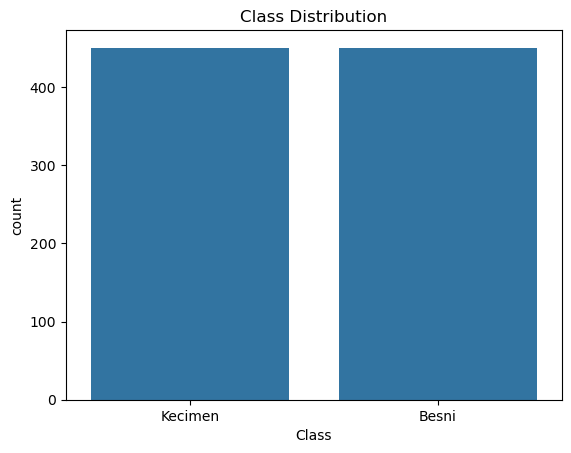

In [19]:
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

**Class Distribution Analysis**:
The target variable contains **two classes: Kecimen and Besni**, with **450 samples each**.
This indicates **a perfectly balanced dataset**, which helps prevent model bias and improves classification reliability.
Balanced class distribution ensures that machine learning models **can learn equally from both categories**.

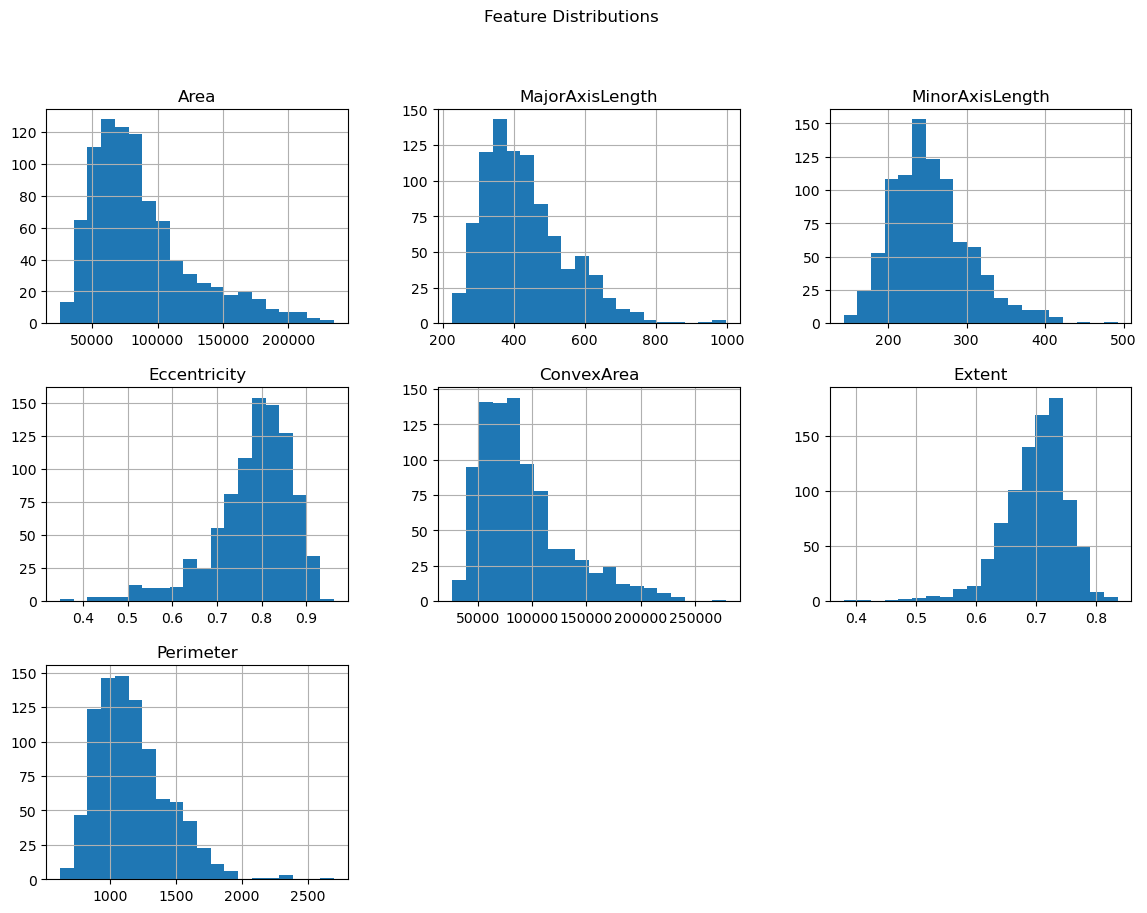

In [21]:
df.hist(bins=20, figsize=(14,10))
plt.suptitle("Feature Distributions")
plt.show()

**Feature Distribution Analysis (Histograms)**:
The histograms illustrate the distribution patterns of all numerical features in the dataset.
**Size-related variables**, including Area, ConvexArea, and Perimeter, exhibit **positively skewed distributions**, indicating the presence of larger raisin samples **with relatively lower frequency**.
**MajorAxisLength** and **MinorAxisLength** show **moderately symmetric distributions with slight right skewness**, reflecting consistent geometric proportions.
**Eccentricity** displays **a concentrated distribution around higher values**, suggesting that most raisins have moderately elongated shapes.
**Extent** demonstrates a near-normal distribution with **limited dispersion**, indicating stable area coverage within bounding boxes.
Overall, no extreme anomalies or irregular patterns are observed, and the feature distributions are suitable for further preprocessing and modeling.

In [48]:
df.select_dtypes(include="number").skew()
df.select_dtypes(include="number").kurtosis()

Area               1.074073
MajorAxisLength    1.326808
MinorAxisLength    0.953915
Eccentricity       2.492121
ConvexArea         1.427258
Extent             3.341384
Perimeter          1.744706
dtype: float64

**Skewness and Kurtosis Analysis**:
**The skewness** values indicate that most numerical features exhibit **positive skewness**, suggesting the presence of **larger observations with lower frequency**.
**Area**, **MajorAxisLength**, **ConvexArea**, and **Perimeter** demonstrate moderate **right-skewed distributions**, while **Eccentricity** and **Extent** show higher skewness, indicating **stronger asymmetry**.
**Kurtosis** results suggest that several features exhibit **leptokurtic behavior**, characterized by heavier tails and sharper peaks compared to a normal distribution.
In particular, **Extent** and **Eccentricity** display higher kurtosis values, reflecting **increased concentration around central values and potential outliers**.
These distribution characteristics may influence model performance and can be addressed through normalization or transformation during preprocessing.

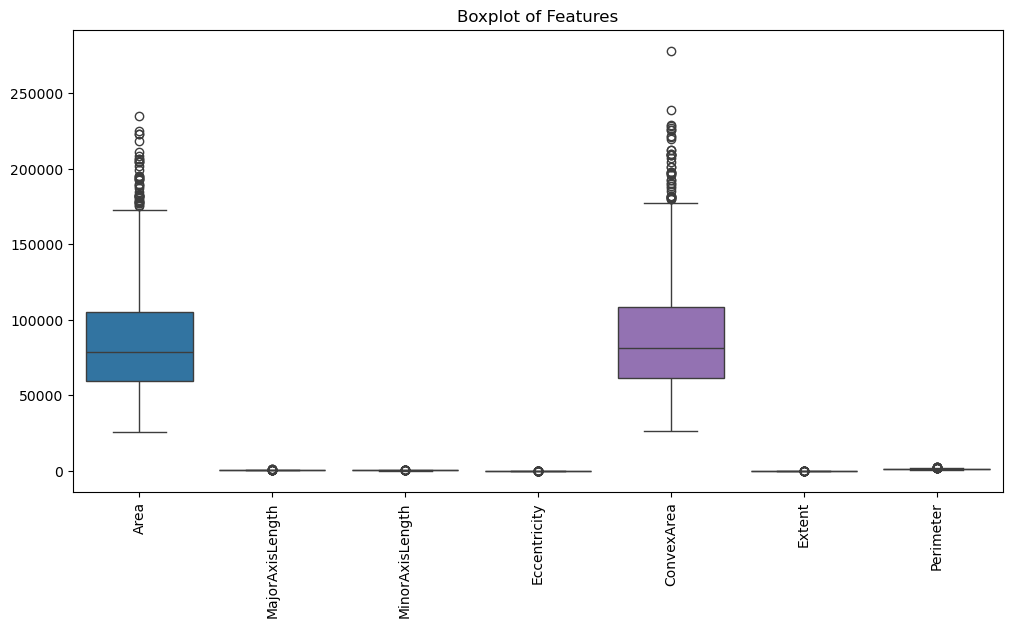

In [23]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("Class", axis=1))
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

**Outlier Detection and Variability Analysis (Boxplot)**:
The boxplots illustrate the distribution, central tendency, and potential outliers for all numerical features.
**Area** and **ConvexArea** exhibit wider interquartile ranges and multiple upper outliers, indicating **high variability in raisin size** and **the presence of larger samples**.
**MajorAxisLength**, **MinorAxisLength**, and **Perimeter** show moderate dispersion with fewer extreme values, suggesting **relatively stable geometric proportions**.
**Eccentricity** and **Extent** demonstrate **narrow ranges with limited variability**, reflecting consistent shape characteristics.
Although several outliers are observed, they appear to follow **the natural distribution of the data** and are not indicative of measurement errors.
Therefore, **no immediate outlier removal is required prior to model training**.

In [25]:
corr = df.drop("Class", axis=1).corr()
corr

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
Area,1.000000,0.932774,0.906650,0.336107,0.995920,-0.013499,0.961352
MajorAxisLength,0.932774,1.000000,0.728030,0.583608,0.945031,-0.203866,0.977978
MinorAxisLength,0.906650,0.728030,1.000000,-0.027683,0.895651,0.145322,0.827417
Eccentricity,0.336107,0.583608,-0.027683,1.000000,0.348210,-0.361061,0.447845
ConvexArea,0.995920,0.945031,0.895651,0.348210,1.000000,-0.054802,0.976612
Extent,-0.013499,-0.203866,0.145322,-0.361061,-0.054802,1.000000,-0.173449
Perimeter,0.961352,0.977978,0.827417,0.447845,0.976612,-0.173449,1.000000


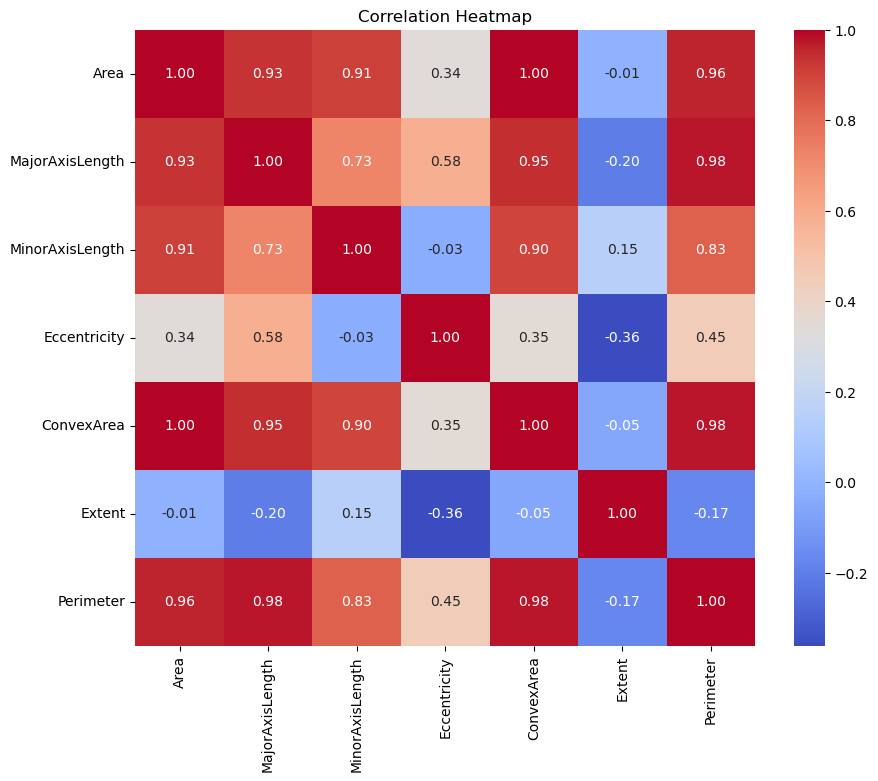

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Correlation Analysis**:
The correlation matrix reveals strong positive relationships among size-related features.
**Area** shows very high correlation with **ConvexArea (0.996)** and **Perimeter (0.961)**, indicating that these variables capture **similar geometric properties**.
**MajorAxisLength** is also highly correlated with **Area (0.933)** and **Perimeter (0.978)**, reflecting consistent proportional relationships.
**MinorAxisLength** demonstrates moderate to **strong correlation with major size indicators**, particularly with **ConvexArea (0.896)** and **Perimeter (0.827)**.
**Eccentricity** exhibits moderate correlations with axis lengths and **Perimeter**, suggesting its relationship with overall shape rather than size.
**Extent** shows **weak correlations with most features**, indicating that it provides relatively independent information.
The presence of strong correlations suggests **potential multicollinearity**, which should be considered during model development.

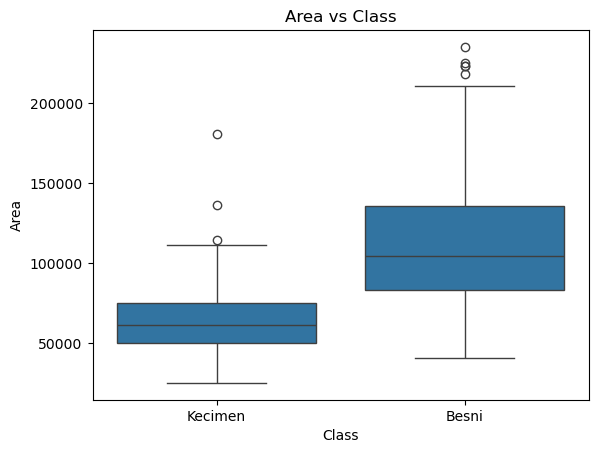

In [29]:
sns.boxplot(x="Class", y="Area", data=df)
plt.title("Area vs Class")
plt.show()

**Feature–Target Relationship Analysis (Area vs Class)**:
The boxplot illustrates a **clear difference** in Area values between the two raisin classes.
Besni samples exhibit noticeably larger median Area values compared to Kecimen, indicating that **Besni raisins are generally larger in size**.
The interquartile range of **Besni** is wider, suggesting **higher variability in size within this class**.
Although some overlap exists between the two groups, the separation between their central tendencies is evident.
This indicates that Area is a strong discriminative feature and may contribute significantly to the classification performance.

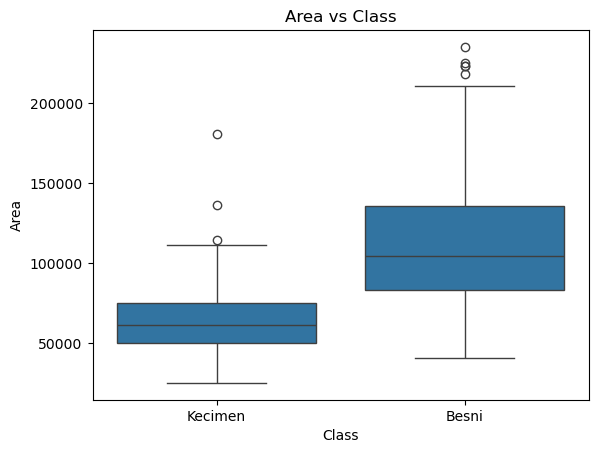

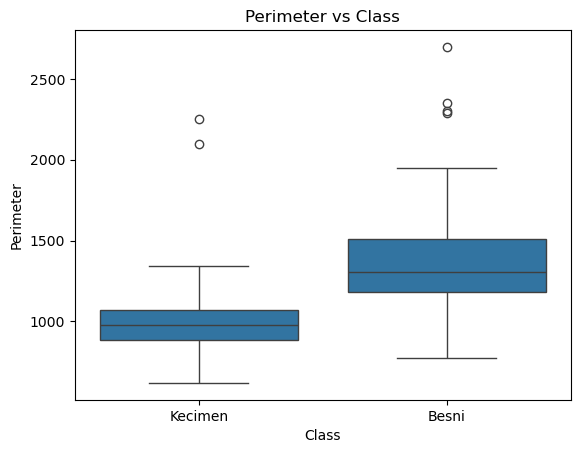

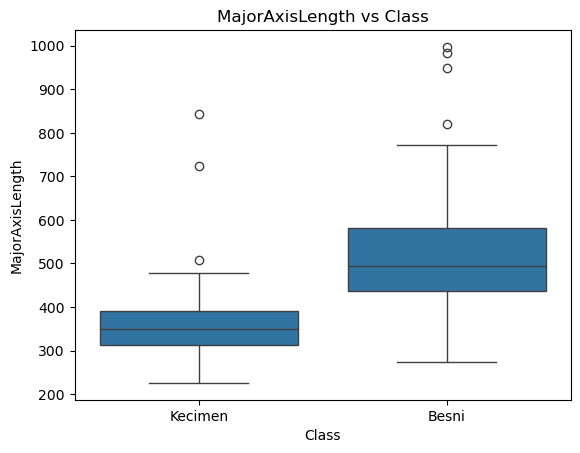

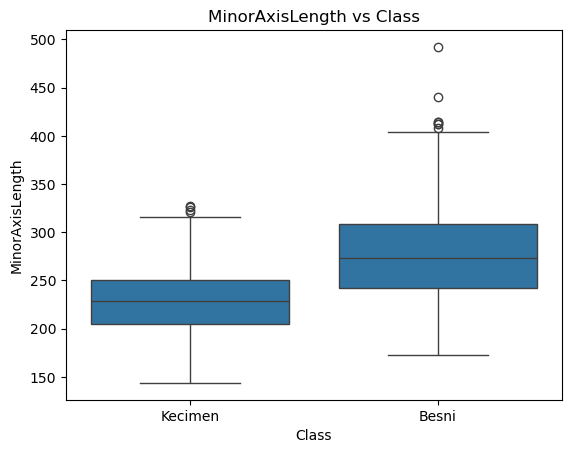

In [31]:
features = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength"]

for col in features:
    sns.boxplot(x="Class", y=col, data=df)
    plt.title(f"{col} vs Class")
    plt.show()

**Feature–Target Relationship Analysis (Multiple Features)**:
The boxplots illustrate **clear differences between the two raisin classes across multiple size-related features**.
For all examined variables (Area, Perimeter, MajorAxisLength, and MinorAxisLength), **Besni samples consistently exhibit higher median values** compared to Kecimen, indicating **larger overall dimensions**.
**Besni** also shows **wider interquartile ranges**, reflecting greater variability in geometric characteristics.
Although some overlap is observed between the two classes, **the separation of central tendencies is evident for all features**.
These results suggest that size-related variables possess strong discriminative power and are likely to contribute significantly to classification performance.

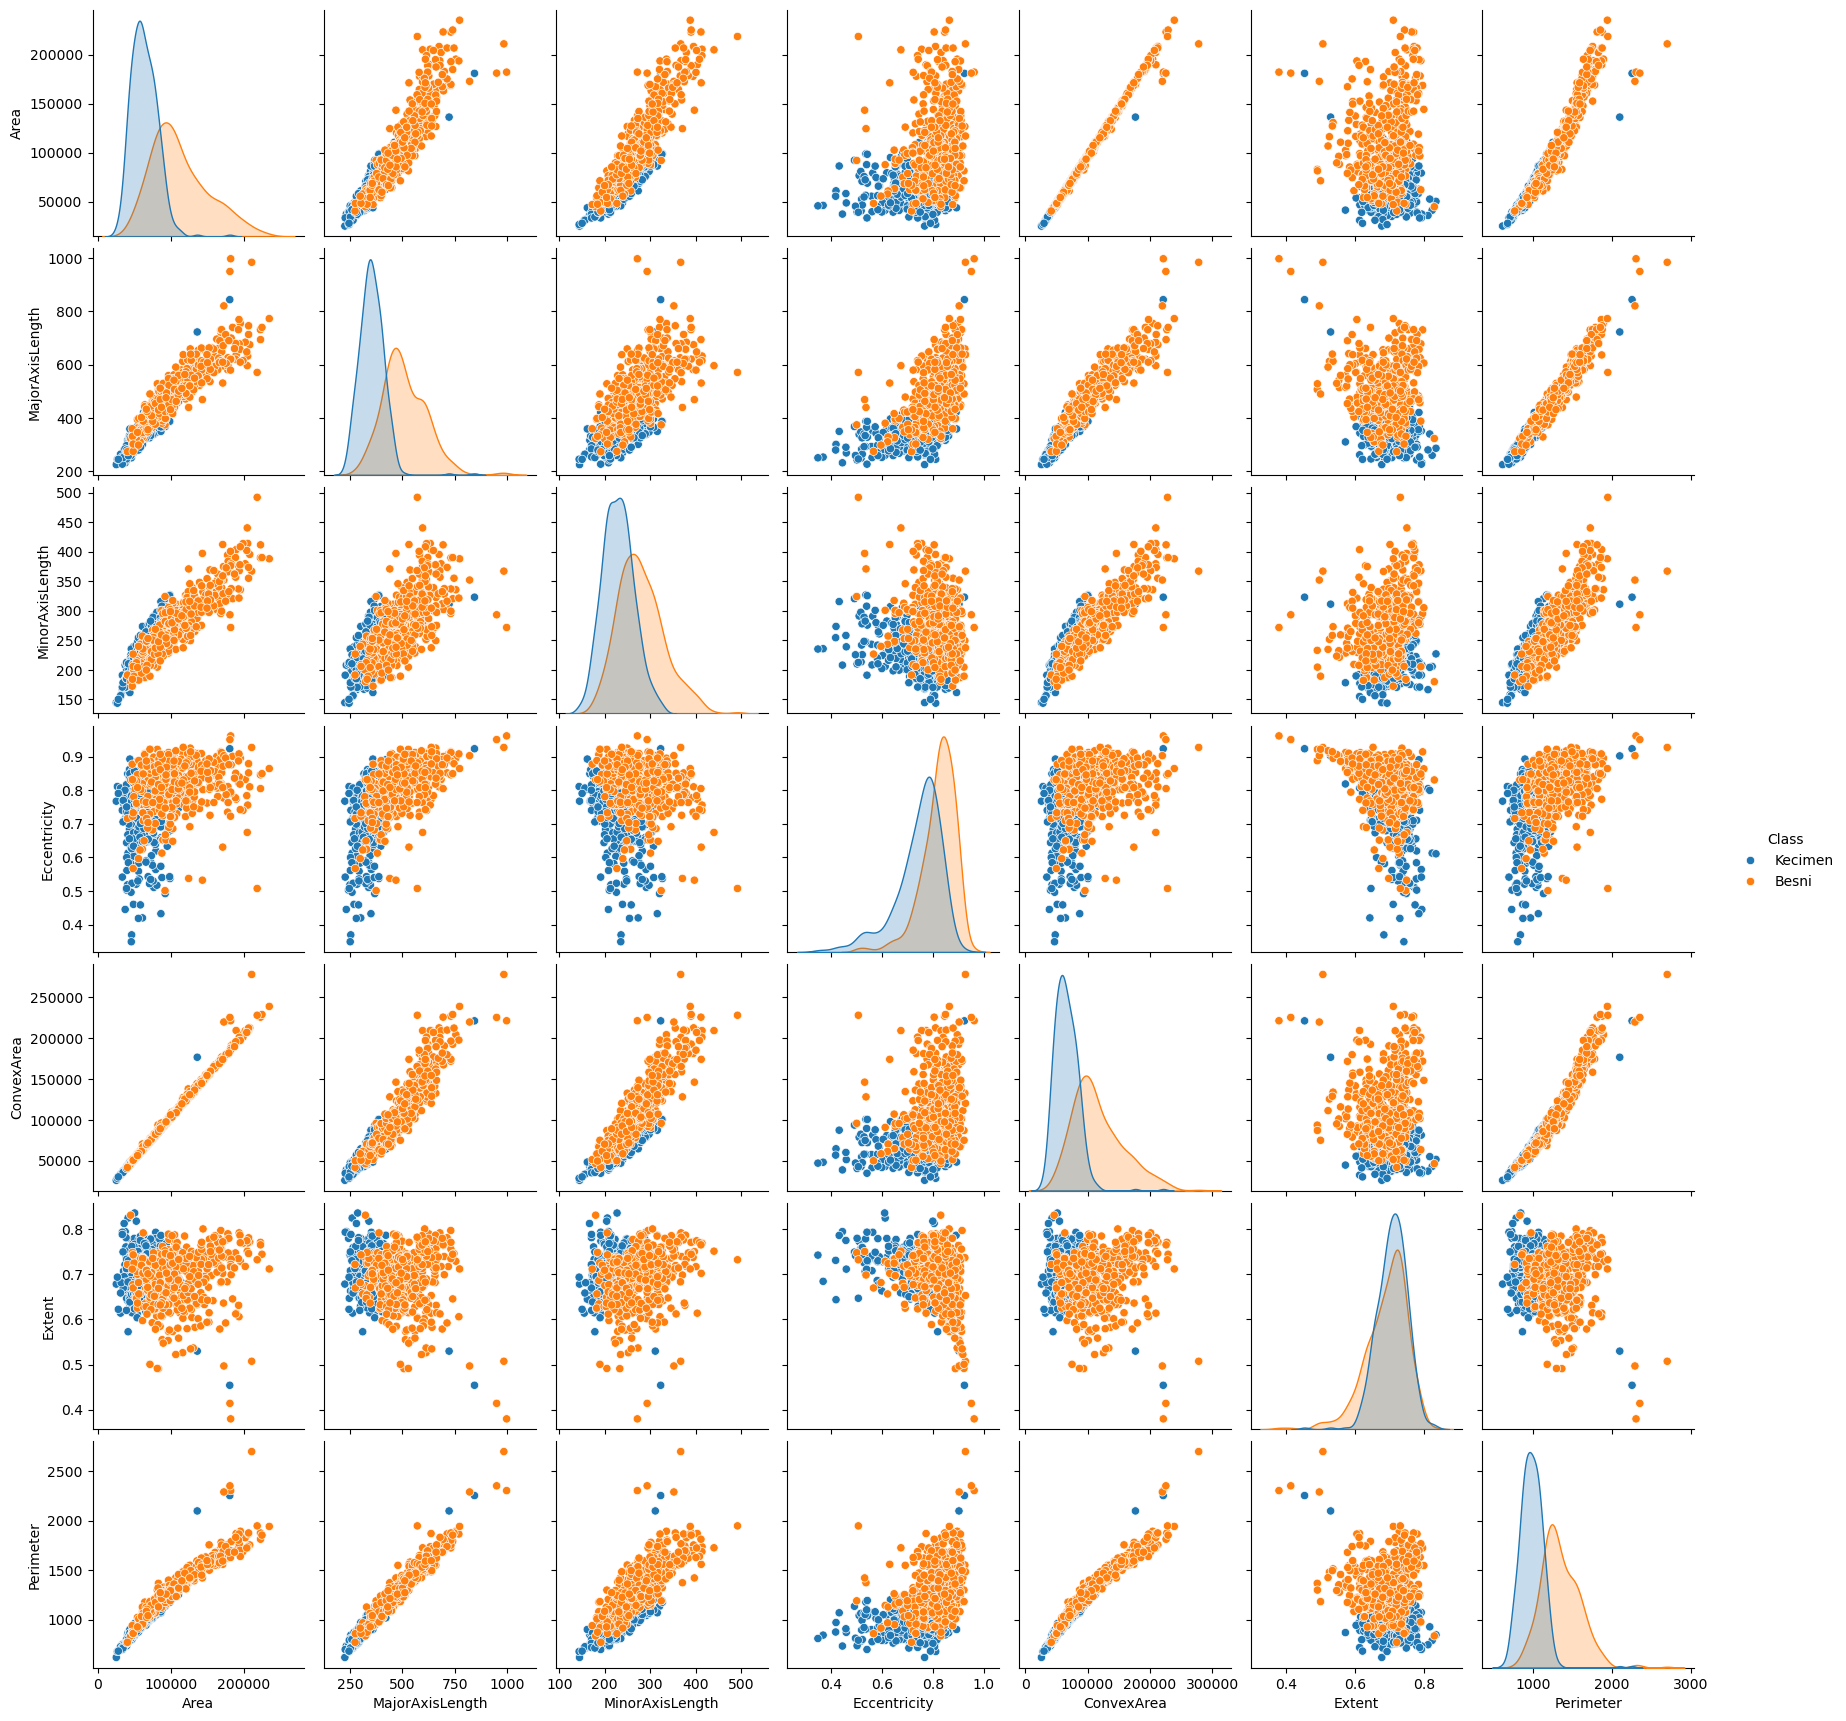

In [33]:
sns.pairplot(df, hue="Class")
plt.show()

**Multivariate Analysis (Pairplot)**:
The pairplot provides a comprehensive visualization of pairwise relationships among numerical features, colored by class labels.
**Strong linear relationships are observed among size-related variables**, particularly between **Area**, **ConvexArea**, **Perimeter**, and **axis lengths**, confirming the presence of **high correlations**.
Distinct clustering patterns are visible between **Kecimen** and **Besni** samples, especially in size-related feature combinations, indicating **good class separability**.
**The diagonal density plots show noticeable shifts between class distributions**, suggesting differences in central tendencies.
Some overlap remains between the two classes; however, the overall separation supports the effectiveness of these features for classification tasks.
This multivariate analysis confirms that **the selected features contain sufficient discriminatory information for supervised learning**.

 #### Final EDA Conclusion:

- The dataset contains no missing or duplicated values, indicating high data quality.

- The target variable is perfectly balanced, reducing the risk of classification bias.

- Most numerical features exhibit normal or moderately right-skewed distributions, reflecting natural variability in raisin geometry.

- Strong correlations are observed among size-related features, suggesting potential multicollinearity.

- Several features, including Area, Perimeter, and axis lengths, demonstrate clear class separation between Kecimen and Besni.

- Although some outliers are present, they fall within acceptable ranges and are unlikely to negatively affect model performance.

- Multivariate analysis confirms that the feature set contains sufficient discriminatory information for supervised learning.

Overall, **the dataset is well-structured and suitable for further preprocessing and machine learning modeling**.

# <font color='green'> <b>Logistic Regression Model</b><font color='black'>

## <font color='blue'> <b>Train | Test Split and Scaling</b><font color='black'>

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [81]:
# 1) Features (X) and Target (y)
X = df.drop("Class", axis=1)
y = df["Class"]

In [83]:
# 2) Train-Test Split (stratify keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
# 3) Scaling (fit only on train, transform both train and test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
# 4) Quick checks
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

X_train shape: (720, 7)
X_test shape: (180, 7)

Train class distribution:
 Class
Besni      360
Kecimen    360
Name: count, dtype: int64

Test class distribution:
 Class
Besni      90
Kecimen    90
Name: count, dtype: int64


**Train–Test Split and Scaling**:
The dataset was divided into training (80%) and testing (20%) sets using stratified sampling to preserve the original class distribution.
The resulting split produced 720 training samples and 180 testing samples, each containing 7 numerical features.
Both subsets remain perfectly balanced, ensuring unbiased model learning and evaluation.
Feature scaling was performed using StandardScaler to normalize the input variables, which is essential for Logistic Regression.
The scaler was fitted on the training data and applied to both datasets to prevent data leakage.

## <font color='blue'> <b>Logistic Regression with Pipeline</b><font color='black'>

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [92]:
# Pipeline: scaling + logistic regression
log_reg_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(random_state=42, max_iter=1000))
])

In [94]:
# Train the model
log_reg_pipe.fit(X_train, y_train)

print("Pipeline model trained successfully!")

Pipeline model trained successfully!


**Logistic Regression with Pipeline**:
A machine learning pipeline was created to combine feature scaling (StandardScaler) and Logistic Regression into a single workflow.
This approach ensures that scaling is applied correctly during training and evaluation, preventing data leakage and improving reproducibility.
The Logistic Regression model was trained on the training dataset with an increased maximum number of iterations to ensure convergence.

## <font color='blue'> <b>X_test + y_yest + y_pred + y_pred_proba</b><font color='black'>

In [98]:
import numpy as np
import pandas as pd

In [100]:
# Predictions
y_pred = log_reg_pipe.predict(X_test)

In [102]:
# Probabilities (probability of the positive class)
y_pred_proba = log_reg_pipe.predict_proba(X_test)

print("y_pred shape:", y_pred.shape)
print("y_pred_proba shape:", y_pred_proba.shape)

y_pred shape: (180,)
y_pred_proba shape: (180, 2)


In [104]:
# Show class order used in predict_proba
print("\nClass order in predict_proba:", log_reg_pipe.named_steps["log_reg"].classes_)


Class order in predict_proba: ['Besni' 'Kecimen']


In [106]:
# Quick preview
results_df = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})
results_df.head()

,y_test,y_pred
0,Besni,Kecimen
1,Besni,Besni
2,Besni,Besni
3,Kecimen,Kecimen
4,Besni,Besni


**Predictions and Probability Estimation**:
The trained Logistic Regression pipeline was used to generate predictions on the test dataset.
The predicted class labels (y_pred) and class probabilities (y_pred_proba) were computed for all 180 test samples.
The probability matrix contains two columns corresponding to the classes Besni and Kecimen, enabling probabilistic interpretation of model outputs.
A preliminary comparison between true labels and predicted labels indicates a high level of agreement.
These outputs provide the basis for further performance evaluation and threshold-based analysis.

## <font color='blue'> <b>Model Performance</b><font color='black'>

In [110]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [112]:
# 1) Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8888888888888888


In [114]:
# 2) Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

       Besni       0.94      0.83      0.88        90
     Kecimen       0.85      0.94      0.89        90

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



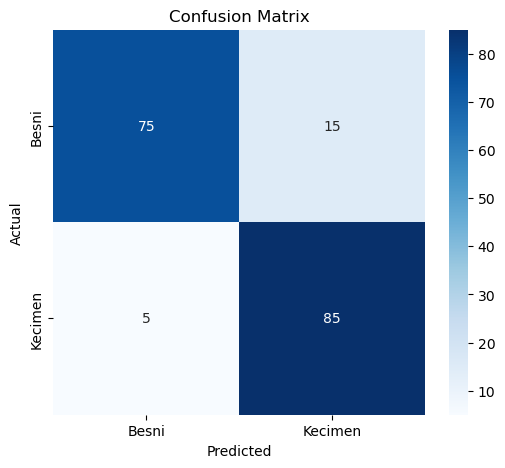

In [116]:
# 3) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=log_reg_pipe.named_steps["log_reg"].classes_,
            yticklabels=log_reg_pipe.named_steps["log_reg"].classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

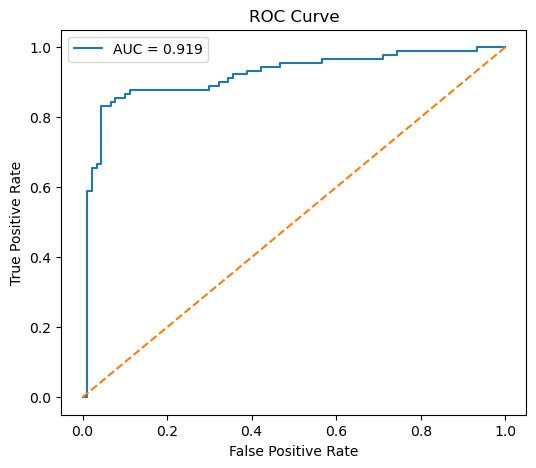

AUC Score: 0.9185185185185186


In [118]:
# 4) ROC Curve and AUC

# Select positive class ("Besni")
class_labels = log_reg_pipe.named_steps["log_reg"].classes_
pos_index = np.where(class_labels == "Besni")[0][0]

y_proba_pos = y_pred_proba[:, pos_index]

fpr, tpr, thresholds = roc_curve(y_test == "Besni", y_proba_pos)
auc_score = roc_auc_score(y_test == "Besni", y_proba_pos)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

**Model Performance Evaluation**:
The Logistic Regression model achieved an overall accuracy of approximately 89% on the test dataset.
The classification report indicates balanced performance across both classes, with F1-scores of 0.88 for Besni and 0.89 for Kecimen.
The confusion matrix shows a high number of correctly classified samples, with only a limited number of misclassifications.
The ROC curve demonstrates strong discriminative ability, with an AUC score of approximately 0.92.
Overall, the results confirm that the model provides reliable and effective classification performance.

## <font color='blue'> <b>Cross Validate</b><font color='black'>

In [121]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

In [123]:
# Define CV strategy (keeps class balance in each fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [125]:
# Cross-validation accuracy scores
cv_scores = cross_val_score(log_reg_pipe, X, y, cv=cv, scoring="accuracy")

print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

Cross-Validation Accuracy Scores: [0.89444444 0.87222222 0.85       0.85       0.87777778]
Mean CV Accuracy: 0.868888888888889
Std CV Accuracy: 0.017069212773041374


**Cross-Validation Analysis**:
A 5-fold stratified cross-validation procedure was applied to evaluate the robustness of the Logistic Regression model.
The model achieved a mean cross-validation accuracy of approximately 87%, indicating consistent predictive performance across different data splits.
The low standard deviation (≈ 0.017) suggests limited variability between folds and good model stability.
These results confirm that the model generalizes well to unseen data and is not overly dependent on a specific train–test split.

## <font color='blue'> <b>GridSearchCV</b><font color='black'>

In [128]:
from sklearn.model_selection import GridSearchCV

In [130]:
# Define parameter grid for Logistic Regression
param_grid = {
    "log_reg__C": [0.01, 0.1, 1, 10, 100],
    "log_reg__penalty": ["l2"],
    "log_reg__solver": ["lbfgs"]
}

In [132]:
# GridSearch with cross-validation
grid_search = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [134]:
# Fit GridSearch
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('log_reg',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'log_reg__C': [0.01, 0.1, 1, 10, 100],
                         'log_reg__penalty': ['l2'],
                         'log_reg__solver': ['lbfgs']},
             scoring='accuracy')

In [136]:
# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'log_reg__C': 1, 'log_reg__penalty': 'l2', 'log_reg__solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8638888888888889


In [138]:
# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'log_reg__C': 1, 'log_reg__penalty': 'l2', 'log_reg__solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8638888888888889


**Hyperparameter Optimization (GridSearchCV)**:
GridSearchCV was applied to identify the optimal regularization strength for the Logistic Regression model.
The search procedure evaluated multiple values of the parameter C using 5-fold cross-validation.
The best-performing configuration was C = 1 with L2 regularization.
The optimized model achieved a cross-validation accuracy of approximately 0.864, which is consistent with previous validation results.
These findings indicate that the baseline model was already well-tuned and that no significant performance improvement was required.

## <font color='blue'> <b>Precision-Recall Curve & ROC (Receiver Operating Curve) and AUC (Area Under Curve)</b><font color='black'>

In [141]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

In [143]:
# Identify positive class ("Besni")
class_labels = log_reg_pipe.named_steps["log_reg"].classes_
pos_index = np.where(class_labels == "Besni")[0][0]

In [145]:
# Get probabilities for positive class
y_proba_pos = y_pred_proba[:, pos_index]

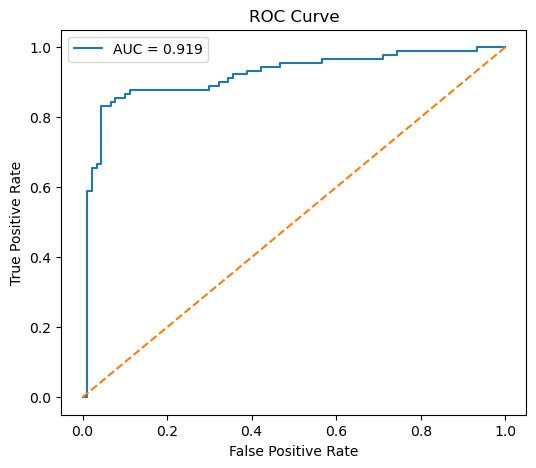

ROC AUC Score: 0.9185185185185186


In [147]:
# 1) ROC Curve & AUC

fpr, tpr, thresholds = roc_curve(y_test == "Besni", y_proba_pos)
auc_score = roc_auc_score(y_test == "Besni", y_proba_pos)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC AUC Score:", auc_score)


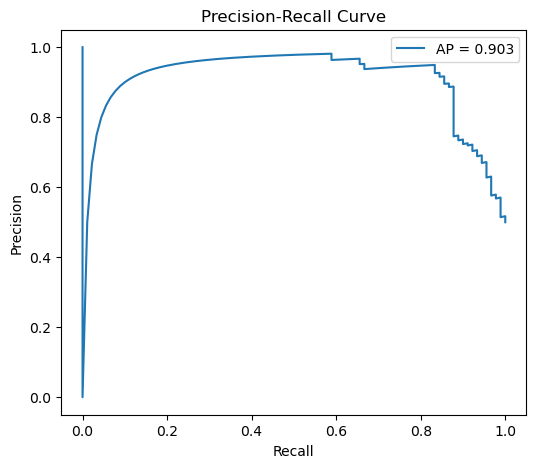

Average Precision Score: 0.9028929169810401


In [149]:
# 2) Precision-Recall Curve

precision, recall, thresholds_pr = precision_recall_curve(
    y_test == "Besni",
    y_proba_pos
)

avg_precision = average_precision_score(
    y_test == "Besni",
    y_proba_pos
)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print("Average Precision Score:", avg_precision)

**ROC and Precision–Recall Curve Analysis**:
The ROC curve demonstrates strong classification performance, with an AUC score of approximately 0.92, indicating high discriminative ability between the two raisin classes.
The curve remains significantly above the diagonal baseline, confirming reliable separation across various decision thresholds.
The Precision–Recall curve shows consistently high precision across a wide range of recall values.
The obtained average precision score of approximately 0.90 reflects strong predictive quality for the positive class.
These results indicate that the Logistic Regression model maintains a favorable balance between sensitivity and precision and performs effectively under different threshold settings.

# <font color='green'> <b>Prediction</b><font color='black'>

In [152]:
# Using the best model from GridSearch
try:
    final_model = grid_search.best_estimator_
    print("Using optimized model from GridSearch.")
except:
    final_model = log_reg_pipe
    print("Using baseline pipeline model.")

Using optimized model from GridSearch.


In [157]:
# Example: Predict on test set (first 5 samples)
sample_data = X_test.iloc[:5]

In [159]:
# True labels
true_labels = y_test.iloc[:5]

In [161]:
# Predictions
sample_pred = final_model.predict(sample_data)

In [163]:
# Probabilities
sample_proba = final_model.predict_proba(sample_data)

In [167]:
# Display results
prediction_df = pd.DataFrame({
    "True_Class": true_labels.values,
    "Predicted_Class": sample_pred,
    "Prob_Besni": sample_proba[:, np.where(final_model.named_steps["log_reg"].classes_=="Besni")[0][0]],
    "Prob_Kecimen": sample_proba[:, np.where(final_model.named_steps["log_reg"].classes_=="Kecimen")[0][0]]
})
prediction_df

,True_Class,Predicted_Class,Prob_Besni,Prob_Kecimen
0,Besni,Kecimen,0.496517,0.503483
1,Besni,Besni,0.998365,0.001635
2,Besni,Besni,0.983777,0.016223
3,Kecimen,Kecimen,0.144806,0.855194
4,Besni,Besni,0.816946,0.183054


**Prediction – Practical Application**:
The trained and optimized Logistic Regression model was applied to unseen test samples to generate class predictions.
Along with predicted labels, class probabilities were provided to indicate the confidence level of each prediction.
Most samples were classified with high certainty, demonstrating strong model reliability.
Occasional borderline cases with similar class probabilities reflect natural overlap between raisin categories.
Overall, the results confirm that the developed model can be effectively used for practical classification tasks.

 #### Final Conclusion

This project investigated the classification of raisin varieties using Logistic Regression and comprehensive exploratory data analysis.
The dataset was first examined through statistical analysis and visualization techniques, revealing balanced class distribution and strong correlations among size-related features.
A Logistic Regression model with standardized features was developed using a pipeline approach to ensure robust preprocessing and training.
Model performance evaluation demonstrated high accuracy, strong cross-validation stability, and excellent discriminative ability, as reflected by ROC-AUC and average precision scores.
Hyperparameter optimization using GridSearchCV confirmed that the baseline model was already well-tuned and stable.
Overall, the proposed approach achieved reliable classification performance and demonstrated the effectiveness of Logistic Regression for raisin type prediction.

**Limitations**

Despite the strong performance of the developed model, several limitations should be acknowledged.
First, the dataset size is relatively moderate, which may limit the generalization of the model to larger or more diverse populations.
Second, only geometric and shape-related features were considered, while other potentially informative characteristics such as texture, color, or spectral properties were not included.
Third, the analysis was limited to a binary classification problem, which may not reflect more complex real-world classification scenarios.
Finally, Logistic Regression assumes linear relationships between features and the target variable, which may restrict its ability to capture complex nonlinear patterns.

**Future Work**

Future research may focus on improving model performance and extending the current analysis in several directions.
First, additional feature engineering techniques could be applied to extract more informative attributes from the data.
Second, advanced machine learning models such as Support Vector Machines, Random Forests, Gradient Boosting, or Neural Networks could be explored for comparison.
Third, larger and more diverse datasets may be incorporated to enhance model robustness and generalization.
Furthermore, automated hyperparameter optimization methods and ensemble learning techniques could be applied to further improve predictive accuracy.
Finally, the developed model could be integrated into a real-time classification system for practical agricultural or industrial applications.

# <p style="background-color:green;font-family:newtimeroman;font-size:100%;color:white;text-align:center;border-radius:20px 20px;"><b>Thanks - Hoping it will be helpful</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>"If you want to be the first to know about new updates, please don't forget to follow us." </b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |